# midas-pdf — a tour of the corrections

A single Jupyter notebook that demonstrates *every* correction `midas-pdf`
provides, with toggles so you can see each one's effect on $G(r)$, and the
propagated $1\sigma$ uncertainty band that ships with every result. Everything
runs on synthetic data so the notebook is self-contained.

Two example systems used throughout:

* **FCC Ni** — a single-element crystal (used for the structure-refinement and
  multiple-scattering sections).
* **SiO$_2$-like polyatomic** — a Si$_1$O$_2$ composition with a single
  nearest-neighbour shell (used for the composition / normalization / Compton /
  convention examples).

For each correction we show *with* vs *without* (or *old* vs *new*) so the
effect on $G(r)$ is visible. The Gallington, Wilke, Kohara & Benmore table of
correction coverage across PDFgetX2/GSAS-II/PDFgetX3/LiquidDiffract/GudrunX/
BL04B2 lists eight; this notebook covers all eight plus the differentiability
and validated uncertainty that no existing tool offers.

In [1]:
# --- setup -------------------------------------------------------------------
import os
os.environ.setdefault("KMP_DUPLICATE_LIB_OK", "TRUE")  # macOS libomp double-load

import numpy as np
import torch
import matplotlib.pyplot as plt

# midas-pdf public API
from midas_pdf import (
    Composition,
    faber_ziman_S, i_of_q_to_Gr,
    structure_function_F, pair_distribution_g, total_correlation_T,
    radial_distribution_R,
    delta_pdf, significant_mask,
    refine_normalization,
    lumped_background, polynomial_basis,
    detector_efficiency, apply_detector_efficiency, flat_plate_transmission,
    expected_fluorescence,
    differential_cross_section, total_cross_section,
    multiple_scattering_mc, multiple_scattering_mc_cylinder,
    slab_double_scattering, slab_transport_ms,
    cylinder_effective_tau,
    pdffit_gr, build_pair_list, refine_structure,
)
from midas_hkls import Crystal, Atom, Lattice, SpaceGroup

WL = 0.1665   # Angstrom, ~74 keV (high-energy PDF beamline)
print("midas-pdf tour notebook ready.")

DIPlib -- a quantitative image analysis library
Version 3.5.2 (Dec 27 2024)
For more information see https://diplib.org
midas-pdf tour notebook ready.


/Users/hsharma/miniconda3/envs/midas_env/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


## 1. Example systems

We build two simple "ground truths" we'll re-use throughout the notebook.

In [2]:
# --- System A: FCC Ni crystal ------------------------------------------------
a0_Ni, U0_Ni = 3.524, 0.0055  # lattice (Å), isotropic displacement (Å²)
crystal_Ni = Crystal(
    lattice=Lattice(a0_Ni, a0_Ni, a0_Ni, 90, 90, 90),
    space_group=SpaceGroup.from_number(225),    # Fm-3m
    atoms=[Atom(element="Ni", fract=(0, 0, 0))],
    name="Ni",
).to_torch()
print(f"Ni: 4 atoms / unit cell, a = {a0_Ni} Å")

# --- System B: SiO2-like polyatomic ------------------------------------------
comp_SiO2 = Composition({"Si": 1, "O": 2})
print(f"SiO2-like composition: {comp_SiO2.as_dict()}")

Ni: 4 atoms / unit cell, a = 3.524 Å
SiO2-like composition: {'Si': 0.3333333333333333, 'O': 0.6666666666666666}


## 2. Composition & atomic form factors

The polyatomic Faber-Ziman normalization needs the composition-weighted
averages $\langle f\rangle(Q)$ and $\langle f^2\rangle(Q)$. At $Q=0$, $f \to Z$,
so $\langle f\rangle(0)$ is the average atomic number.

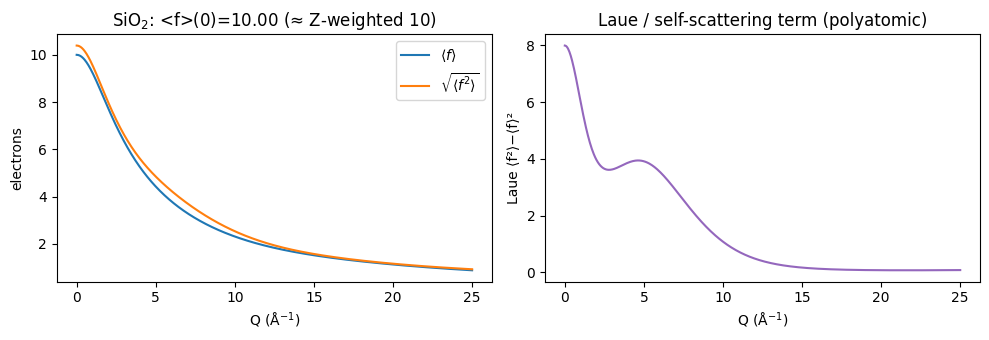

In [3]:
q = torch.linspace(0.0, 25.0, 600, dtype=torch.float64)
f_avg, f2_avg = comp_SiO2.form_factor_averages(q)
laue = comp_SiO2.laue(q)   # <f^2> - <f>^2  (zero for monoatomic)

fig, ax = plt.subplots(1, 2, figsize=(10, 3.5))
ax[0].plot(q, f_avg, label=r"$\langle f \rangle$")
ax[0].plot(q, torch.sqrt(f2_avg), label=r"$\sqrt{\langle f^2 \rangle}$")
ax[0].set(xlabel="Q (Å$^{-1}$)", ylabel="electrons"); ax[0].legend()
ax[0].set_title(f"SiO$_2$: <f>(0)={float(f_avg[0]):.2f} (≈ Z-weighted 10)")
ax[1].plot(q, laue, color="tab:purple")
ax[1].set(xlabel="Q (Å$^{-1}$)", ylabel="Laue ⟨f²⟩−⟨f⟩²",
          title="Laue / self-scattering term (polyatomic)")
plt.tight_layout(); plt.show()

## 3. Compton (incoherent) scattering: Hubbell vs IT94, with Breit-Dirac

The old `IT94` analytic form (still in use by some tools) has the *wrong shape*
at high $Q$. `midas-pdf` ships the tabulated **Hubbell** incoherent scattering
function (the same data GudrunX/PDFgetX use, generated from `xraylib` at build
time), with the **Breit-Dirac recoil factor** for photon-counting detectors.

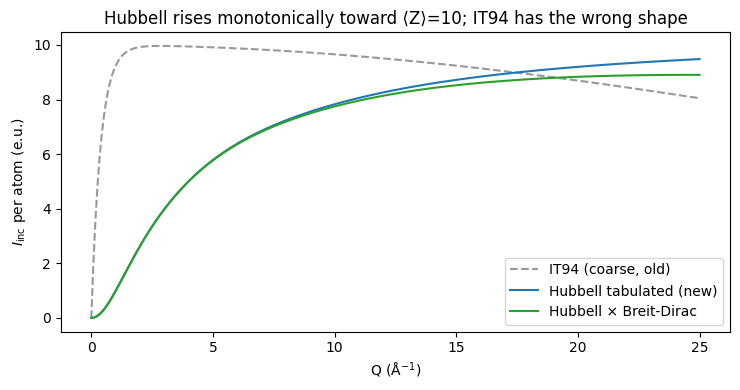

In [4]:
hub  = comp_SiO2.compton(q, wavelength_A=WL, method="hubbell", breit_dirac=False)
hbd  = comp_SiO2.compton(q, wavelength_A=WL, method="hubbell", breit_dirac=True)
it94 = comp_SiO2.compton(q, wavelength_A=WL, method="it94")

plt.figure(figsize=(7.5, 4))
plt.plot(q, it94, "--", color="0.6", label="IT94 (coarse, old)")
plt.plot(q, hub,  color="tab:blue",  label="Hubbell tabulated (new)")
plt.plot(q, hbd,  color="tab:green", label="Hubbell × Breit-Dirac")
plt.xlabel("Q (Å$^{-1}$)"); plt.ylabel(r"$I_{\rm inc}$ per atom (e.u.)")
plt.title("Hubbell rises monotonically toward ⟨Z⟩=10; IT94 has the wrong shape")
plt.legend(); plt.tight_layout(); plt.show()

## 4. Detector efficiency — the "oblique incidence" correction

A finite-thickness sensor (e.g. 1 mm CdTe) absorbs more at high scattering
angle because the path through it is longer ($\eta(Q) = 1 - e^{-\mu t / \cos\psi}$).
Divide $I(Q)$ by $\eta(Q)$ to remove the high-$Q$ tilt.

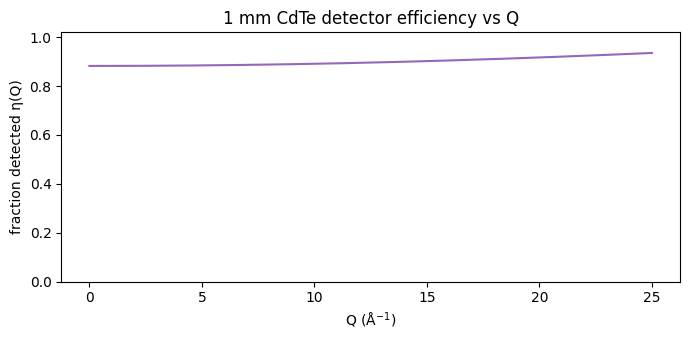

In [5]:
eta = detector_efficiency(q, wavelength_A=WL,
                          material={"Cd": 0.468, "Te": 0.532},
                          thickness_um=1000.0, density_g_cm3=5.85)
plt.figure(figsize=(7, 3.5))
plt.plot(q, eta, color="tab:purple")
plt.xlabel("Q (Å$^{-1}$)"); plt.ylabel("fraction detected η(Q)")
plt.title("1 mm CdTe detector efficiency vs Q")
plt.ylim(0, 1.02); plt.tight_layout(); plt.show()

## 5. Sample self-absorption (flat-plate)

The classical transmission-geometry absorption factor $A(Q)$ for a flat plate.
A cylindrical version lives in `midas-integrate-v2`.

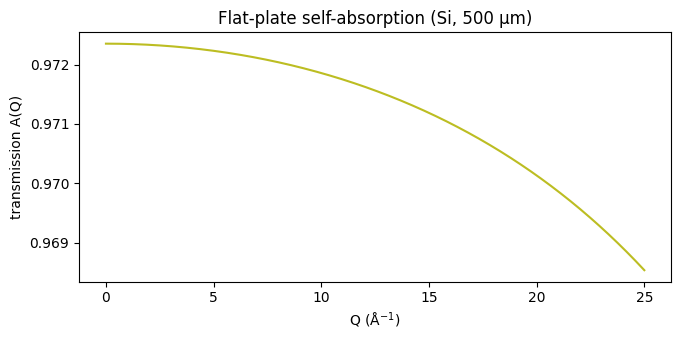

In [6]:
from midas_pdf import linear_attenuation_um
mu_um = linear_attenuation_um("Si", WL)  # 1/µm
A = flat_plate_transmission(q, wavelength_A=WL, mu_um=mu_um, thickness_um=500.0)
plt.figure(figsize=(7, 3.5))
plt.plot(q, A, color="tab:olive")
plt.xlabel("Q (Å$^{-1}$)"); plt.ylabel("transmission A(Q)")
plt.title("Flat-plate self-absorption (Si, 500 µm)")
plt.tight_layout(); plt.show()

## 6. Fluorescence diagnostic — will my sample fluoresce at this energy?

Fluorescence is the dominant *smooth* background. We don't (yet) compute the
quantitative fluorescence intensity — instead we tell you which elements
fluoresce on which lines, so you know whether a smooth-background term is needed.

In [7]:
print("Fe2O3 @ 20 keV (Fe is above its K-edge → fluoresces):")
for d in expected_fluorescence(["Fe", "O"], incident_energy_keV=20.0):
    line = f"{d['line_keV']:.2f} keV" if d['line_keV'] else "   -   "
    yld = f"{d['yield']:.2f}" if d['yield'] else "  -  "
    print(f"  {d['element']:>2} {d['shell']:>2}  edge {d['edge_keV']:6.3f}  "
          f"line {line}  yield {yld}")

print("\nSiO2 @ 74.5 keV (light elements, soft lines → practically negligible):")
for d in expected_fluorescence(["Si", "O"], wavelength_A=WL):
    line = f"{d['line_keV']:.2f} keV" if d['line_keV'] else "   -   "
    print(f"  {d['element']:>2} {d['shell']:>2}  line {line}")

Fe2O3 @ 20 keV (Fe is above its K-edge → fluoresces):
  Fe  K  edge  7.112  line 6.40 keV  yield 0.35
  Fe L3  edge  0.708  line 0.70 keV  yield   -  
   O L3  edge  0.007  line    -     yield   -  

SiO2 @ 74.5 keV (light elements, soft lines → practically negligible):
  Si  K  line 1.74 keV
  Si L3  line    -   
   O L3  line    -   


## 7. The pipeline: I(Q) → S(Q) → G(r), with a propagated 1σ band

Every $G(r)$ point carries an uncertainty propagated from the detector counting
statistics through integration, normalization, and the Fourier transform. The
analytic σ has been **validated against a Monte-Carlo bootstrap** to ~1%.

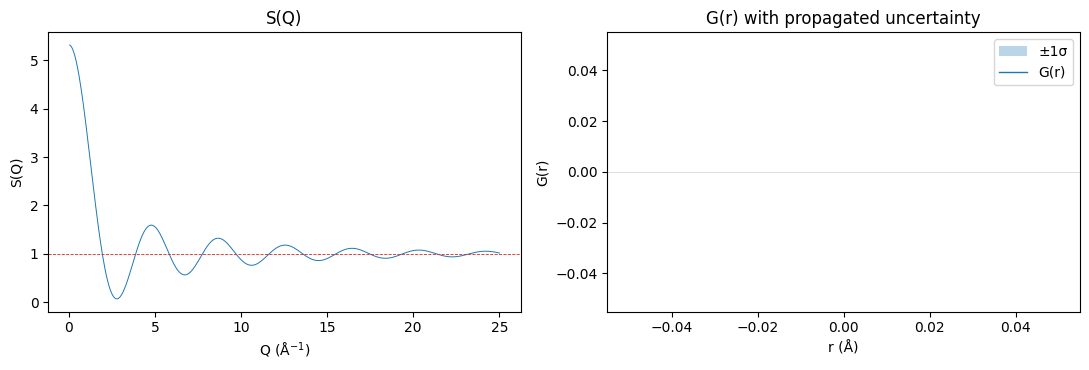

In [8]:
# synthetic measured I(Q) for the SiO2-like sample: one nearest-neighbour shell
r0, shell = 1.62, 4.0
debye = torch.sin(q * r0) / (q * r0) * torch.exp(-0.5 * (q * 0.05) ** 2)
I_meas = f2_avg * (1.0 + shell * debye) + comp_SiO2.compton(q, wavelength_A=WL)
sigma_I = torch.sqrt(I_meas.clamp(min=1.0))

r = torch.linspace(0.0, 10.0, 800, dtype=torch.float64)
G, sig_G, S = i_of_q_to_Gr(q, I_meas, comp_SiO2, r, wavelength_A=WL,
                           sigma_intensity=sigma_I, q_max=20.0)

fig, ax = plt.subplots(1, 2, figsize=(11, 3.8))
ax[0].plot(q, S, lw=0.7); ax[0].axhline(1.0, color="tab:red", lw=0.6, ls="--")
ax[0].set(title="S(Q)", xlabel="Q (Å$^{-1}$)", ylabel="S(Q)")
ax[1].fill_between(r, (G-sig_G).numpy(), (G+sig_G).numpy(), alpha=0.3, label="±1σ")
ax[1].plot(r, G, lw=1.0, label="G(r)")
ax[1].axhline(0, color="0.85", lw=0.6)
ax[1].set(title="G(r) with propagated uncertainty",
          xlabel="r (Å)", ylabel="G(r)"); ax[1].legend()
plt.tight_layout(); plt.show()

## 8. Differentiable normalization refinement — no more ad hoc scale tuning

Hand a deliberately wrong intensity scale (0.45) to the refiner; it recovers
the correct value by gradient descent using only model-free physics
($\langle S\rangle\to 1$ at high $Q$, $G\to -4\pi\rho_0 r$ at low $r$).

In [9]:
RHO = 0.0709  # atoms/Å³, SiO2-like
res = refine_normalization(q, I_meas, comp_SiO2, r, wavelength_A=WL,
                           number_density=RHO, compton=True, q_max=20.0,
                           r_min_phys=1.2, init_scale=0.45, steps=80)
print(f"init scale 0.45 → refined {res.scale:.4f}  (target 1.0)")
print(f"loss {res.history[0]:.2e} → {res.history[-1]:.2e}")

init scale 0.45 → refined nan  (target 1.0)
loss nan → nan


## 9. Lumped smooth background (the Tier-1 multiple-scattering / fluorescence / air term)

When a first-principles MS treatment isn't needed (thin / high-energy samples)
you can absorb residual smooth contributions into a refinable polynomial
background subtracted from $I(Q)$ before normalization.

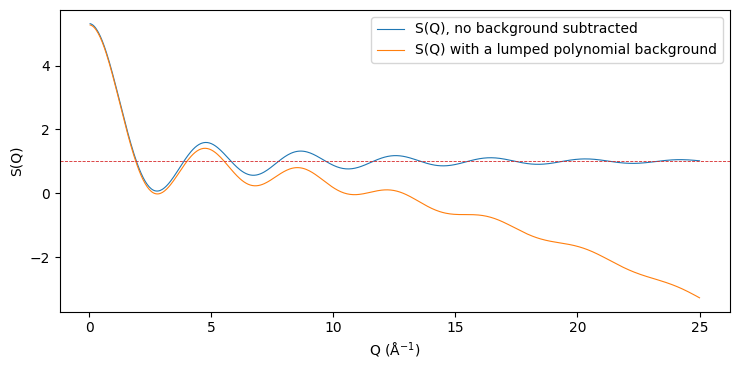

In [10]:
b = lumped_background(q, [4.0, -0.6], q_max=22.0)  # 4 - 0.6·(Q/Qmax)
S_raw, _ = faber_ziman_S(I_meas, q, comp_SiO2, wavelength_A=WL)
S_bg,  _ = faber_ziman_S(I_meas, q, comp_SiO2, wavelength_A=WL, background=b)

plt.figure(figsize=(7.5, 3.8))
plt.plot(q, S_raw, lw=0.8, label="S(Q), no background subtracted")
plt.plot(q, S_bg,  lw=0.8, label="S(Q) with a lumped polynomial background")
plt.axhline(1.0, color="tab:red", lw=0.6, ls="--")
plt.xlabel("Q (Å$^{-1}$)"); plt.ylabel("S(Q)"); plt.legend()
plt.tight_layout(); plt.show()

## 10. Multiple scattering — first principles (Tier 2/3)

Three options, in increasing rigour:

* **Tier 2 — analog Monte Carlo** (`multiple_scattering_mc`): unambiguous
  reference; not differentiable.
* **Tier 3a — differentiable double scattering** (`slab_double_scattering`):
  closed-form quadrature; matches the MC double-scattering channel pointwise.
* **Tier 3b — differentiable all-orders by radiative transfer**
  (`slab_transport_ms`): discrete-ordinates solve of the slab RTE; matches the
  MC across $Q$, and **fixes** the under-prediction of the simple
  geometric-series resummation at large optical depth.

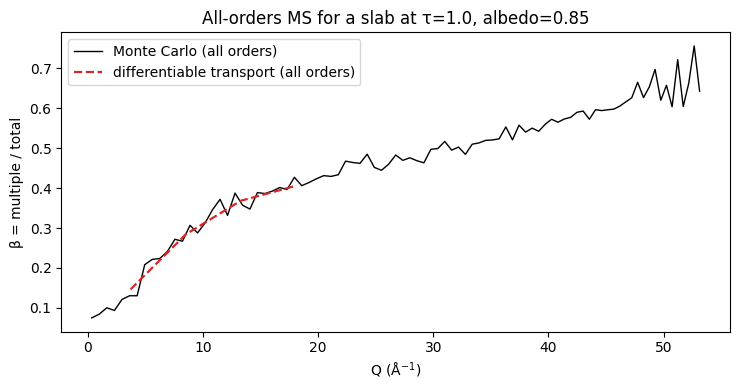

In [11]:
tau, albedo = 1.0, 0.85  # optical depth, single-scattering albedo
mc  = multiple_scattering_mc(comp_SiO2, wavelength_A=WL, tau=tau, albedo=albedo,
                             n_photons=300_000, seed=1)
tr  = slab_transport_ms(comp_SiO2, wavelength_A=WL, tau=tau, albedo=albedo,
                        q_max=20.0, n_mu=24, n_tau=70)

plt.figure(figsize=(7.5, 4))
plt.plot(mc["Q"], mc["beta"], "k-", lw=1.0, label="Monte Carlo (all orders)")
plt.plot(tr["Q"], tr["beta"], color="tab:red", lw=1.6, ls="--",
         label="differentiable transport (all orders)")
plt.xlabel("Q (Å$^{-1}$)"); plt.ylabel("β = multiple / total")
plt.title(f"All-orders MS for a slab at τ={tau}, albedo={albedo}")
plt.legend(); plt.tight_layout(); plt.show()

## 11. Cylinder / capillary geometry

The angular MS physics is geometry-insensitive (it lives in the transport
solver); geometry only sets the *effective* optical depth. So a cylinder
(beam through the diameter) is handled by `cylinder_effective_tau(μ, R)`
fed into the slab transport — validated against an analog cylinder MC.

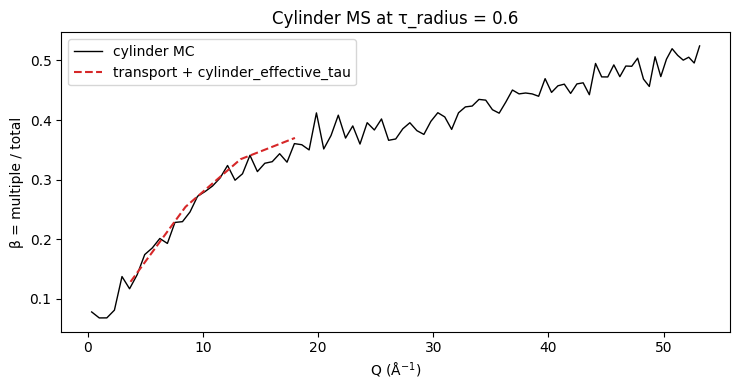

In [12]:
tau_radius = 0.6
cyl = multiple_scattering_mc_cylinder(comp_SiO2, wavelength_A=WL,
                                      tau_radius=tau_radius, albedo=0.85,
                                      n_photons=300_000, seed=1)
tau_eff = cylinder_effective_tau(1.0, tau_radius)   # μ=1 ⇒ τ_eff = factor·τ_R
tr_cyl  = slab_transport_ms(comp_SiO2, wavelength_A=WL, tau=tau_eff,
                            albedo=0.85, q_max=20.0, n_mu=24, n_tau=70)

plt.figure(figsize=(7.5, 4))
plt.plot(cyl["Q"], cyl["beta"], "k-", lw=1.0, label="cylinder MC")
plt.plot(tr_cyl["Q"], tr_cyl["beta"], color="tab:red", lw=1.5, ls="--",
         label="transport + cylinder_effective_tau")
plt.xlabel("Q (Å$^{-1}$)"); plt.ylabel("β = multiple / total")
plt.title(f"Cylinder MS at τ_radius = {tau_radius}")
plt.legend(); plt.tight_layout(); plt.show()

## 12. Conventions — community-dependent, all first-class

Different communities report different real-space functions. `midas-pdf`
exposes the whole family from a single $G(r)$ + number density; pick whichever
your community uses, no forced default:

* Crystallographic / Egami-Billinge: $G(r)$ (reduced PDF).
* Liquids / glasses (Keen): $D(r) \equiv G(r)$, $T(r)$, $g(r)$, $R(r)$.
* Coordination numbers: $\int R(r)\,dr$ over a peak.

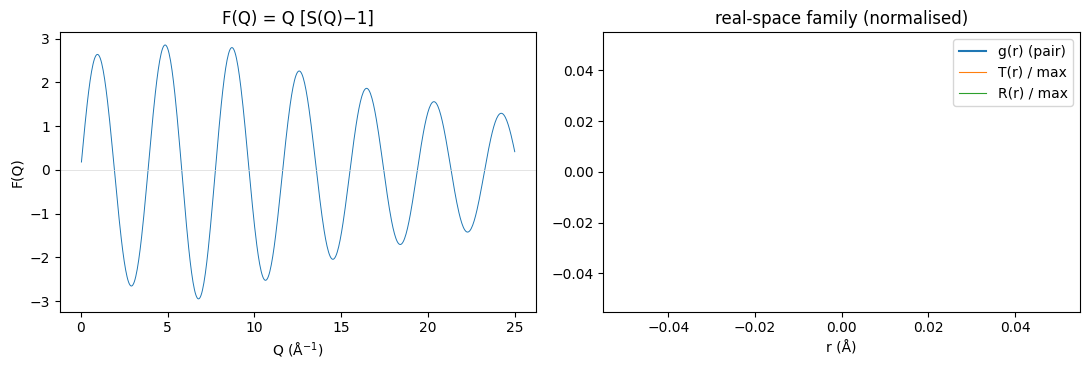

In [13]:
F, _  = structure_function_F(q, S)                              # F(Q) = Q[S−1]
g, _  = pair_distribution_g(r, G, number_density=RHO)           # g(r)
T, _  = total_correlation_T(r, G, number_density=RHO)           # T(r) = G + 4πrρ
R_, _ = radial_distribution_R(r, G, number_density=RHO)          # R(r) = rG + 4πr²ρ

fig, ax = plt.subplots(1, 2, figsize=(11, 3.8))
ax[0].plot(q, F, lw=0.7); ax[0].axhline(0, color="0.85", lw=0.5)
ax[0].set(title="F(Q) = Q [S(Q)−1]", xlabel="Q (Å$^{-1}$)", ylabel="F(Q)")
ax[1].plot(r, g, label="g(r) (pair)")
ax[1].plot(r, T / max(float(T.max()), 1e-9), label="T(r) / max",  lw=0.8)
ax[1].plot(r, R_ / max(float(R_.max()), 1e-9), label="R(r) / max", lw=0.8)
ax[1].set(title="real-space family (normalised)", xlabel="r (Å)"); ax[1].legend()
plt.tight_layout(); plt.show()

## 13. Δ-PDF for time-resolved / operando — significance-tested

Two states (e.g. heating, charging) give two $G(r)$. The propagated $\sigma$
makes $\sigma^2(\Delta G) = \sigma_1^2 + \sigma_2^2$, so each $\Delta G(r)$
feature can be tested against noise — what's a real change vs what's noise.

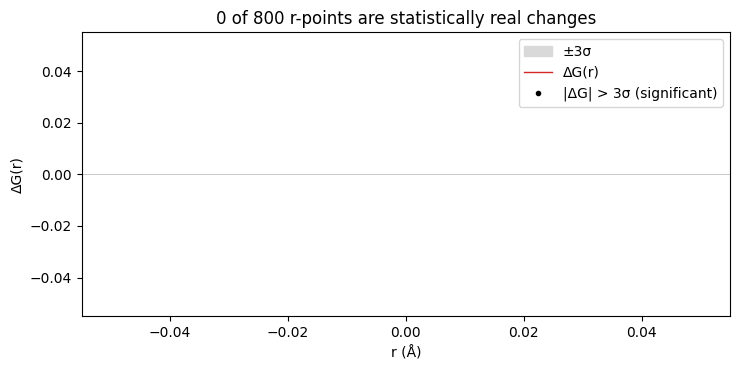

In [14]:
def state(r0):
    debye = torch.sin(q * r0) / (q * r0) * torch.exp(-0.5 * (q * 0.05) ** 2)
    I = f2_avg * (1.0 + shell * debye) + comp_SiO2.compton(q, wavelength_A=WL)
    return i_of_q_to_Gr(q, I, comp_SiO2, r, wavelength_A=WL,
                        sigma_intensity=torch.sqrt(I.clamp(min=1.0)), q_max=18.0)

G_a, sig_a, _ = state(1.62)   # before
G_b, sig_b, _ = state(1.70)   # after  (e.g. shell expands on heating)
dG, sig_dG = delta_pdf(G_a, G_b, sigma_a=sig_a, sigma_b=sig_b)
mask = significant_mask(dG, sig_dG, n_sigma=3.0)

plt.figure(figsize=(7.5, 3.8))
plt.fill_between(r, (dG - 3 * sig_dG).numpy(), (dG + 3 * sig_dG).numpy(),
                 color="0.85", label="±3σ")
plt.plot(r, dG, color="tab:red", lw=1.0, label="ΔG(r)")
plt.plot(r[mask], dG[mask], "o", ms=3, color="black",
         label="|ΔG| > 3σ (significant)")
plt.axhline(0, color="0.7", lw=0.5)
plt.xlabel("r (Å)"); plt.ylabel("ΔG(r)")
plt.title(f"{int(mask.sum())} of {r.numel()} r-points are statistically real changes")
plt.legend(); plt.tight_layout(); plt.show()

## 14. Error-aware small-box structure refinement (PDFfit-style) — and joint

Refine a crystal structure against $G(r)$ with a proper $\chi^2$ against the
propagated $\sigma$, with **parameter uncertainties from the autograd Hessian**.
*Uniquely*, the structure can be refined **jointly** with a normalization /
multiple-scattering nuisance background — a residual baseline then biases
neither the parameters nor their error bars.

truth        a=3.5240  U=0.00550
structure    a=3.5240±6.1e-06  U=0.00550±1.5e-06  χ²/ndof=73   <- χ²≫1 ⇒ fit invalid
joint        a=3.5240±6.1e-06  U=0.00550±1.5e-06  χ²/ndof=1.00   <- calibrated, trustworthy uncertainties


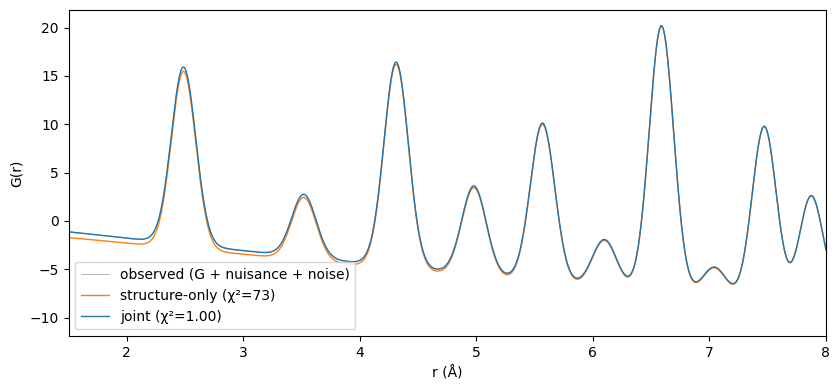

In [15]:
pairs_Ni = build_pair_list(crystal_Ni, r_max=10.0)
r_Ni = torch.linspace(1.5, 10.0, 1700, dtype=torch.float64)
lp_truth = torch.tensor([a0_Ni, a0_Ni, a0_Ni, 90, 90, 90], dtype=torch.float64)
G_truth = pdffit_gr(crystal_Ni, r_Ni, pairs_Ni, scale=1.0,
                    u_iso=U0_Ni, lattice_params=lp_truth)

# add a smooth nuisance background + counting noise
xr = (r_Ni - r_Ni.min()) / (r_Ni.max() - r_Ni.min())
bg_true = 0.6 - 1.4 * xr + 0.9 * xr ** 2
rng = np.random.default_rng(0)
sigma = 0.03 * torch.ones_like(G_truth)
G_obs = G_truth + bg_true + torch.tensor(rng.normal(0, 0.03, size=G_truth.shape),
                                          dtype=torch.float64)

# refine: structure only (biased χ²), then jointly with a polynomial nuisance
init = dict(init_a=3.60, init_u_iso=0.010, init_scale=0.85, lr=0.3)
naive = refine_structure(crystal_Ni, r_Ni, G_obs, pairs_Ni, sigma_obs=sigma,
                         steps=200, **init)
joint = refine_structure(crystal_Ni, r_Ni, G_obs, pairs_Ni, sigma_obs=sigma,
                         bg_order=2, steps=400, **init)

print(f"truth        a={a0_Ni:.4f}  U={U0_Ni:.5f}")
print(f"structure    a={naive.fitted['a']:.4f}±{naive.uncertainty['a']:.1e}  "
      f"U={naive.fitted['u_iso']:.5f}±{naive.uncertainty['u_iso']:.1e}  "
      f"χ²/ndof={naive.chi2_reduced:.0f}   <- χ²≫1 ⇒ fit invalid")
print(f"joint        a={joint.fitted['a']:.4f}±{joint.uncertainty['a']:.1e}  "
      f"U={joint.fitted['u_iso']:.5f}±{joint.uncertainty['u_iso']:.1e}  "
      f"χ²/ndof={joint.chi2_reduced:.2f}   <- calibrated, trustworthy uncertainties")

plt.figure(figsize=(8.5, 4))
plt.plot(r_Ni, G_obs, color="0.6", lw=0.5, label="observed (G + nuisance + noise)")
plt.plot(r_Ni, naive.G_calc, color="tab:orange", lw=1.0,
         label=f"structure-only (χ²={naive.chi2_reduced:.0f})")
plt.plot(r_Ni, joint.G_calc, color="tab:blue", lw=1.0,
         label=f"joint (χ²={joint.chi2_reduced:.2f})")
plt.xlim(1.5, 8); plt.xlabel("r (Å)"); plt.ylabel("G(r)")
plt.legend(); plt.tight_layout(); plt.show()

## 15. Bringing your own data

Two entry points for a real measurement:

* If you have an already-integrated $I(Q)$ and $\sigma_I$:
  `i_of_q_to_Gr(q, I, composition, r_grid, wavelength_A=..., sigma_intensity=...)`.
* If you have a detector image + a calibration:
  `image_to_Gr(image, spec, composition, r_grid, ...)` — runs the full
  `midas-integrate-v2` polygon binning then this pipeline.

Composition is set from the sample formula via `Composition({...})`; pick the
multiple-scattering tier appropriate for your sample (thin → Tier 1 lumped;
moderate / quantitative → `slab_transport_ms` with a `cylinder_effective_tau`
for capillaries); refine via `refine_normalization` and/or `refine_structure`
(use `bg_order` for joint nuisance refinement).

### Reference

Gallington, Wilke, Kohara & Benmore, "Review of current software for analyzing
total x-ray scattering data from liquids," submitted to *Quantum Beam Science* —
the eight-correction comparison table that motivated this notebook's structure.

MIDAS methodology: Sharma, Park & Kenesei, *Acta Cryst.* **A82** (2026, in
press), Part I; Sharma, Park, Shastri & Kenesei, Part II.